# Marketing Campaign Conversion Analysis

## Project Overview

This project analyzes marketing campaign performance and customer behavior to identify the key factors driving customer conversion. The analysis combines exploratory data analysis (EDA) and machine learning techniques to uncover actionable marketing insights.

In [2]:
import pandas as pd

df = pd.read_csv("../data/digital_marketing_campaign_dataset.csv")



## Data Understanding

Before conducting the analysis, the dataset is explored to understand its structure, identify missing values, and examine the distribution of key variables.

In [3]:
df.head()
df.describe()
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [ ]:
df.columns


Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='str')

## Business question 1: Which channels and campaign types generate the highest conversion?

In [ ]:

#Conversion by campaign channel
df.groupby("CampaignChannel")["Conversion"].mean().sort_values(ascending=False)
#Referral channel generate highest conversion rate

CampaignChannel
Referral        0.883072
PPC             0.882779
SEO             0.876774
Email           0.870263
Social Media    0.868334
Name: Conversion, dtype: float64

In [ ]:
#Conversion by campaign type
df.groupby("CampaignType")["Conversion"].mean().sort_values(ascending=False)
#Conversion campaign type generate highest conversion rate

CampaignType
Conversion       0.933558
Retention        0.858243
Consideration    0.855634
Awareness        0.855634
Name: Conversion, dtype: float64

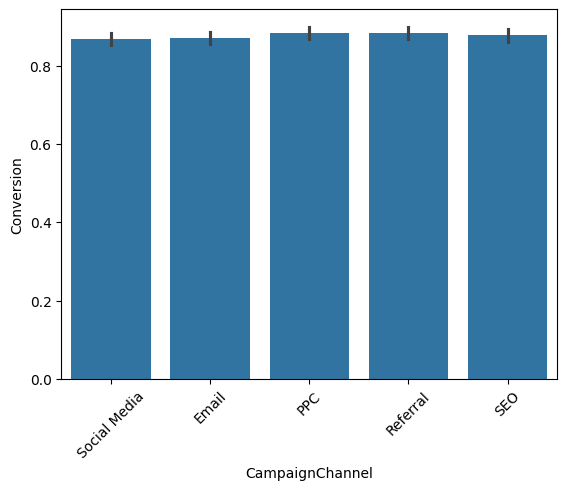

In [11]:
#Visualization
sns.barplot(data=df, x="CampaignChannel", y="Conversion")
plt.xticks(rotation=45)
plt.show()

## Business question 2:  Which customer groups are most likely to convert?

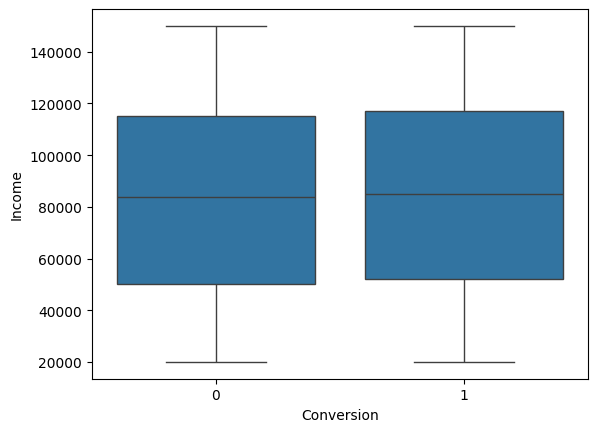

In [ ]:


df.groupby("Gender")["Conversion"].mean()
#Male customers have higher conversion

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","55+"]
)

df.groupby("AgeGroup")["Conversion"].mean()
#Customers aged 36-45 have highest conversion rate

sns.boxplot(x="Conversion", y="Income", data=df)
plt.show()
#Customers who converted vs those who not converted have same income distribution


## Business Question 3: What behaviors indicated higher conversion?

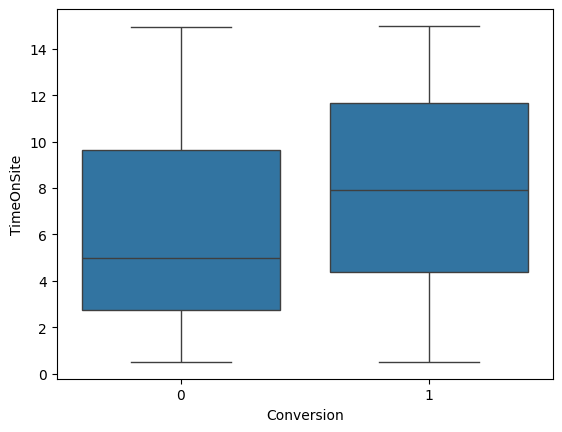

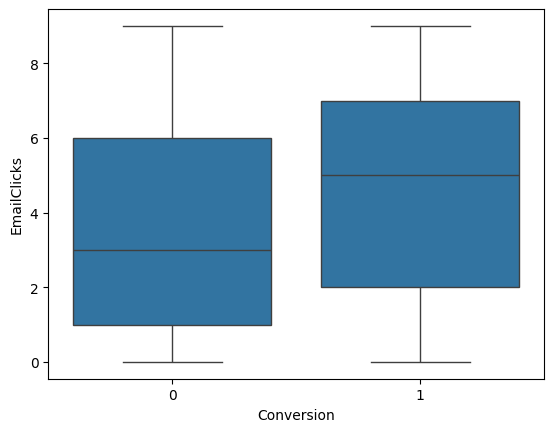

In [ ]:


#Time on site vs conversion
sns.boxplot(x="Conversion", y="TimeOnSite", data=df)
plt.show()
#Customers who converted have higher time on site

#Email clicks vs conversion
sns.boxplot(x="Conversion", y="EmailClicks", data=df)
plt.show()
#Customers who converted have higher email clicks

## Business question 4: Does higher advertising spend improve conversion?

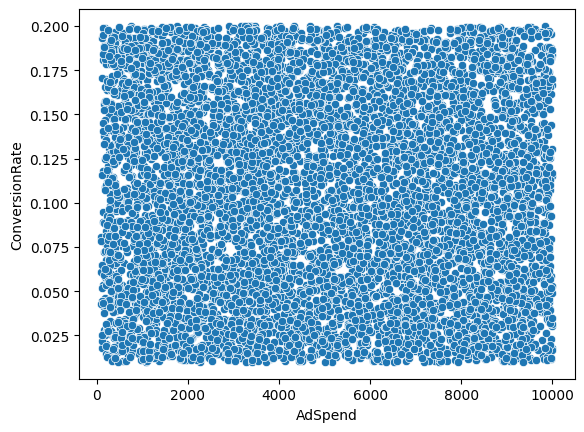

In [ ]:

sns.scatterplot(x="AdSpend", y="ConversionRate", data=df)
plt.show()
#Ad spend showed little clear relationship with conversion rate, indicating that increased budget alone does not guarantee stronger campaign performance.

## Business question 5: Which campaign combinations perform best?

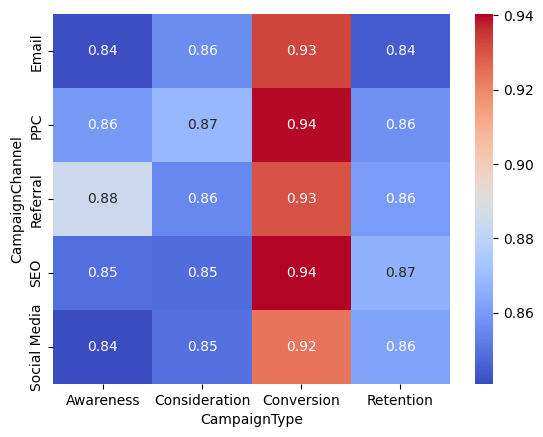

In [ ]:

pivot = df.pivot_table(
    values="Conversion",
    index="CampaignChannel",
    columns="CampaignType",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.show()

#PPC channel - Conversion type and SEO-channel - Conversion type perform best

## Business question 6: Are loyal customers more likely to convert?

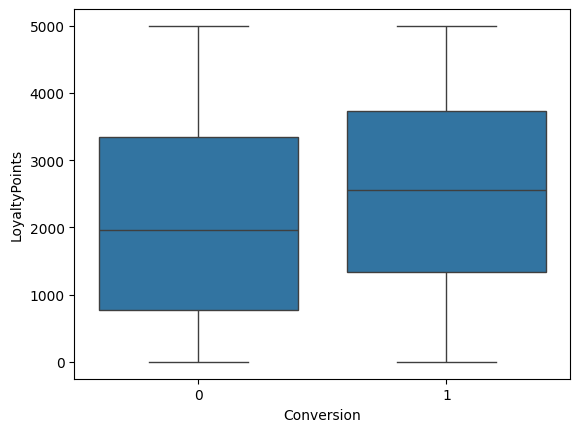

In [ ]:

sns.boxplot(x="Conversion", y="LoyaltyPoints", data=df)
plt.show()

#Customers who converted have higher loyalty points

## Business question 7: Do email opens, email clicks drive conversions? 

In [ ]:

df.groupby("Conversion")["EmailOpens"].mean()
#Customers who converted have higher average email opens

df.groupby("Conversion")["EmailClicks"].mean()
#Customers who converted have higher average email clicks


Conversion
0    3.481781
1    4.606246
Name: EmailClicks, dtype: float64

## Business question 8: What factors had strong/weak correlation with conversion?

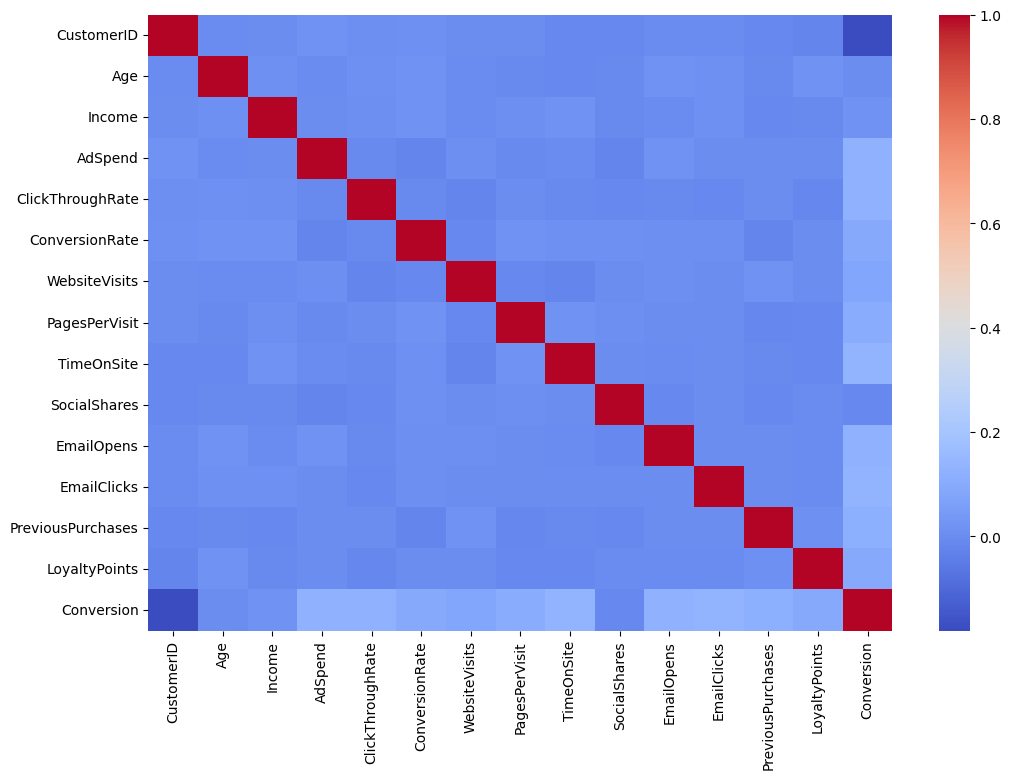

In [ ]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

##Email clicks and opens show positive correlation with conversion
#Previous purchases and loyalty points also show positive correlation with conversion
#PagesPerVisit,TimeOnSite, WebsiteVisits also show positive correlation with conversion
#Age, income show weak correlation with conversion
#Behavioral engagement metrics such as email interactions, website activity, and loyalty indicators demonstrated stronger relationships with conversion than demographic variables such as age and income.

## Business question 9: Predict whether a customer converts

C:\Users\VU HAI\AppData\Local\Temp\ipykernel_21588\3910888903.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns


Accuracy: 0.700625

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.56      0.31       194
           1       0.92      0.72      0.81      1406

    accuracy                           0.70      1600
   macro avg       0.57      0.64      0.56      1600
weighted avg       0.84      0.70      0.75      1600



c:\Users\VU HAI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


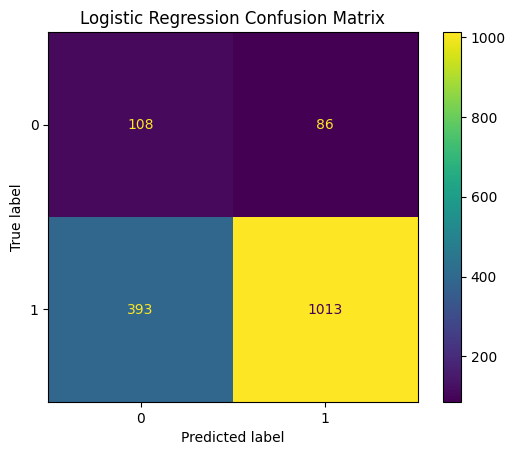

Accuracy: 0.881875

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.05      0.10       194
           1       0.88      1.00      0.94      1406

    accuracy                           0.88      1600
   macro avg       0.78      0.52      0.52      1600
weighted avg       0.86      0.88      0.83      1600



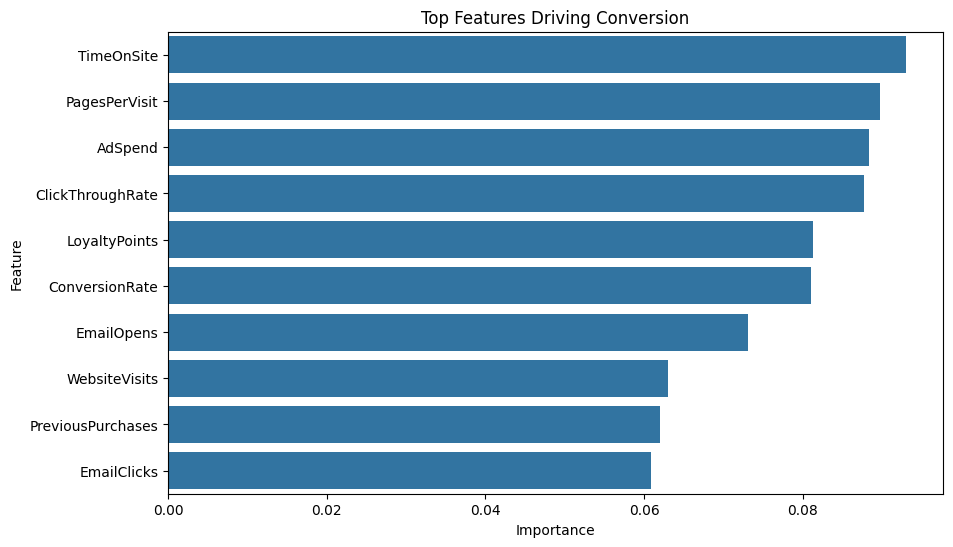

[1]


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,AgeGroup
2215,42,0,84067,4,3,4763.087209,0.264393,0.020226,35,2.328249,11.836823,25,12,4,1,365,0,0,2


In [ ]:

# Predictive Analytics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(["CustomerID", "Conversion"], axis=1)

y = df["Conversion"]

label_encoder = LabelEncoder()

categorical_cols = X.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
    log_model = LogisticRegression(max_iter=1000,    class_weight="balanced")

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

#Class 0: recall 0.01: the model only identified 1% of actual non-converters correctly.

#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

#logistic regression recall for class 0 is 0.56; random forest recall for class 0 is 0.05

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

#Which variables were most important for predicting customer conversion: customer engagement behaviors


plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Driving Conversion")

plt.show()

#TimeOnSite, PagesPerVisit: Customers who spend more time browsing and exploring the website are more likely to convert.
#Clickthroughrate: Customers who actively interact with advertisements are more likely to convert.
#LoyaltyPoints, PreviousPurchases: existing loyal customers are more likely to convert again.
#email opens, email clicks: email engagement contributes to customer conversion probability.

sample_customer = X_test.iloc[[0]]

prediction = log_model.predict(sample_customer)

print(prediction)

sample_customer

#the model predicted this customer will convert, because This customer has MANY characteristics associated with converters (high website visits
#long time on site, high email opens, high email clicks)

### Logistic Regression Results

The initial Logistic Regression model achieved high accuracy but struggled to identify non-converted customers due to class imbalance. A balanced version of the model improved minority-class detection.

### Random Forest Results

Random Forest achieved higher overall accuracy but demonstrated weaker performance in identifying non-converted customers compared with Logistic Regression.

### Feature Importance Analysis

Feature importance analysis revealed that customer engagement metrics were the strongest predictors of conversion.

Top predictors:
- TimeOnSite
- PagesPerVisit
- AdSpend
- ClickThroughRate
- LoyaltyPoints

These findings suggest that customer behavior is more influential than demographic characteristics when predicting conversion.

### Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Increase website engagement initiatives to improve conversion rates.
- Prioritize customers with strong engagement signals.
- Strengthen loyalty programs to encourage repeat conversions.
- Improve email marketing effectiveness through higher engagement strategies.
- Focus on behavioral targeting rather than demographic segmentation alone.

### Conclusion

This analysis found that customer engagement and loyalty indicators were the strongest drivers of conversion. Machine learning models further confirmed that behavioral metrics such as TimeOnSite and PagesPerVisit were more predictive of conversion than demographic variables.